# Gesture Recognition using Satellite Signal Sensing

This notebook demonstrates gesture classification using XGBoost on satellite signal data. We compare the performance of:
1. **Without FineSat (W/O FineSat)**: Raw signals without inter-satellite differential processing
2. **With FineSat (W/ FineSat)**: Signals after inter-satellite differential processing

In [17]:
# Import required libraries
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import shuffle
import torch
import matplotlib.pyplot as plt
import seaborn as sns

## Data Format

The dataset consists of:
- **X (Features)**: Shape (1000, 200) - 1000 samples, each with 200 sampling points per gesture
- **Y (Labels)**: Shape (1000,) - 1000 labels, each is an integer from 0-4 representing 5 different gestures:
  - 0: Push
  - 1: Push & Pull
  - 2: Triangle
  - 3: Draw 'M'
  - 4: Star

In [18]:
# Load and inspect data format
# X (features): shape (1000, 200) - 1000 samples with 200 sampling points per gesture
X = torch.load("WO_FineSat_X.pth", weights_only=False) 
# Y (labels): shape (1000,) - 1000 samples, each label is an integer from 0-4
# representing 5 different gestures: push, push&pull, triangle, draw 'M', star
Y = torch.load("WO_FineSat_Y.pth", weights_only=False)  
print(f"Features shape: {X.shape}, Labels shape: {Y.shape}")

Features shape: (1000, 200), Labels shape: (1000,)


## Experiment 1: Without FineSat (Raw Signals)

Train and evaluate XGBoost classifier on raw satellite signals without inter-satellite differential processing.

Test set accuracy: 0.81
Confusion Matrix:
[[34  8  0  0  0]
 [14 21  5  0  0]
 [ 3  6 31  0  0]
 [ 0  0  0 42  1]
 [ 0  0  0  1 34]]


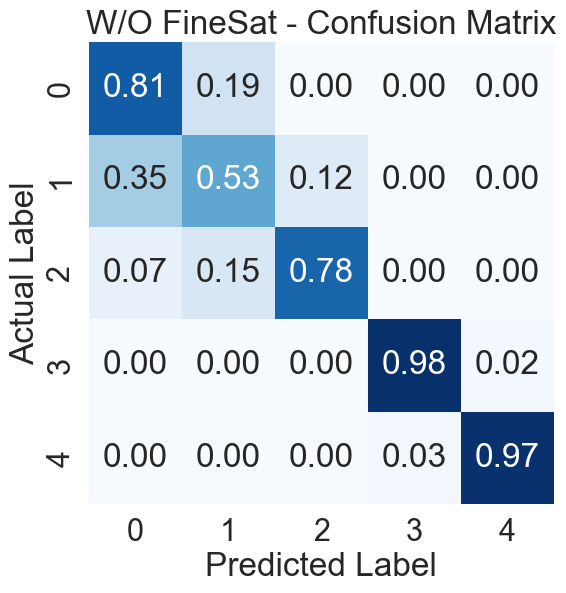

In [19]:
# W/O FineSat: Raw signals without inter-satellite differential processing
X = torch.load("WO_FineSat_X.pth", weights_only=False) 
Y = torch.load("WO_FineSat_Y.pth", weights_only=False) 

# Shuffle the data for randomization
X, Y = shuffle(X, Y, random_state=0)

seed_origin = 20

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed_origin)

# Create XGBoost classifier
model = XGBClassifier()

# Train the model
model.fit(X_train, Y_train)

# Predict on test set
Y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Test set accuracy: {accuracy}")

# Compute and display confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
# Convert confusion matrix to percentage form
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
print("Confusion Matrix:")
print(conf_matrix)

# Format confusion matrix with 2 decimal places
formatted_confusion_matrix = np.around(conf_matrix, decimals=2)
formatted_confusion_matrix = formatted_confusion_matrix.astype('float') / formatted_confusion_matrix.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 6))
sns.set(font_scale=2)  # Adjust font size
sns.heatmap(formatted_confusion_matrix, annot=True, cbar=False, fmt='.2f', cmap='Blues', 
            xticklabels=np.arange(5), yticklabels=np.arange(5))
plt.title("W/O FineSat - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Experiment 2: With FineSat (Differential Signals)

Train and evaluate XGBoost classifier on signals after inter-satellite differential processing.

Test set accuracy: 0.825
Confusion Matrix:
[[32 12  0  0  0]
 [12 20  0  0  0]
 [ 0  4 45  0  0]
 [ 0  0  0 31  6]
 [ 0  0  0  1 37]]


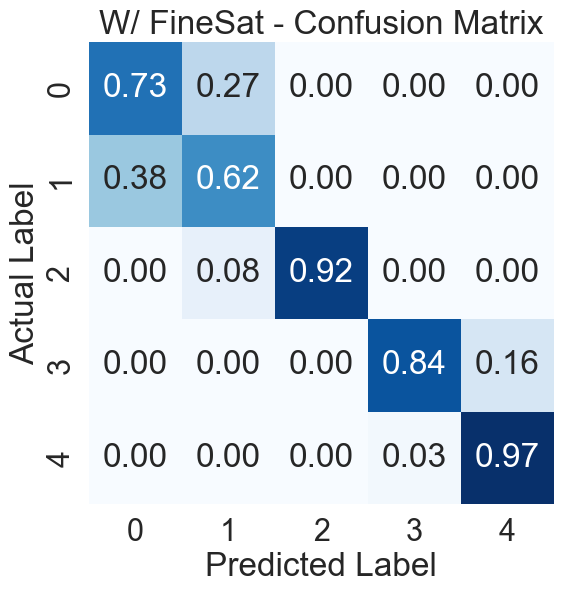

In [20]:
# W/ FineSat: Signals after inter-satellite differential processing
X = torch.load("WO_FineSat_X.pth", weights_only=False)
Y = torch.load("WO_FineSat_Y.pth", weights_only=False) 

# Shuffle the data for randomization
X, Y = shuffle(X, Y, random_state=0)

seed_finesat = 42

# Split data into training and test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed_finesat)

# Create XGBoost classifier
model = XGBClassifier()

# Train the model
model.fit(X_train, Y_train)

# Predict on test set
Y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Test set accuracy: {accuracy}")

# Compute and display confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred)
# Convert confusion matrix to percentage form
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100
print("Confusion Matrix:")
print(conf_matrix)

# Format confusion matrix with 2 decimal places
formatted_confusion_matrix = np.around(conf_matrix, decimals=2)
formatted_confusion_matrix = formatted_confusion_matrix.astype('float') / formatted_confusion_matrix.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix using Seaborn
plt.figure(figsize=(6, 6))
sns.set(font_scale=2)  # Adjust font size
sns.heatmap(formatted_confusion_matrix, annot=True, cbar=False, fmt='.2f', cmap='Blues', 
            xticklabels=np.arange(5), yticklabels=np.arange(5))
plt.title("W/ FineSat - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()